# Imports

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import joblib

# Functions

In [ ]:
def remove_constant_columns(data):
  for i in data.columns:
    if data[i].max() == data[i].min():
      data = data.drop(columns=[i])
  return data

In [ ]:
def feature_selection(X, y, columns, label_column):
  np_data = np.column_stack([X, y])
  pd_data = pd.DataFrame(data=np_data, columns=[columns])
  corr_mat = pd_data.corr(method='pearson').abs()
  label_corr = corr_mat[label_column]

  label_corr = label_corr[label_corr > 0.3].dropna()
  label_corr = label_corr[label_corr < 0.99].dropna()

  features = label_corr.index
  features = [item[0] for item in features]
  features = np.array(features)

  # print(features)
  return features, corr_mat

# Train

              precision    recall  f1-score   support

           0   0.999928  0.999973  0.999951    222303
           1   0.999966  0.999910  0.999938    177205

    accuracy                       0.999945    399508
   macro avg   0.999947  0.999941  0.999944    399508
weighted avg   0.999945  0.999945  0.999945    399508



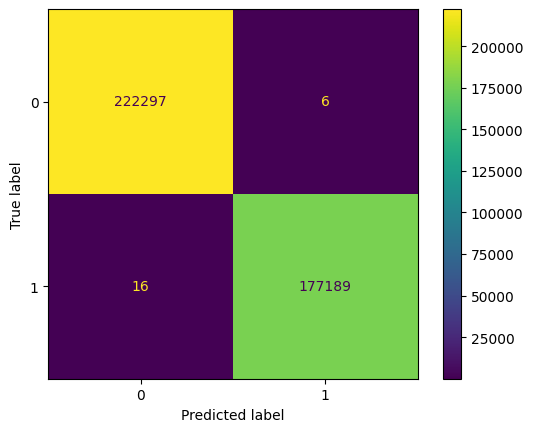

In [ ]:
# Load dataset
data = pd.read_csv('labeledMessages.csv')

# Pre process data
data = data.dropna()
data = remove_constant_columns(data)
X = data.drop(columns=['label'])
y = data['label']

# Split to train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, shuffle=True)

# Normalize data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = pd.DataFrame(data=X_train, columns=X.columns)
X_test = pd.DataFrame(data=X_test, columns=X.columns)

# Feature selection
features, corr_mat = feature_selection(X_train, y_train, data.columns, 'label')
X_train = X_train[features]
X_test = X_test[features]

# Train model
classifier = DecisionTreeClassifier()
model = classifier.fit(X_train, y_train)

joblib.dump(model, "dt.joblib")
joblib.dump(scaler, "dt_scaler.joblib")

# Evaluate best model by test data
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, digits=6))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()